# Loading Libraries

In [92]:
import nltk                                  # Python library for NLP
from nltk.corpus import twitter_samples      # sample Twitter dataset from NLTK
import matplotlib.pyplot as plt              
import numpy as np                           
import random

In [93]:
# !pip install nltk

# Loading Dataset

In [94]:
# downloads sample twitter dataset. uncomment the line below if running on a local machine.
nltk.download('twitter_samples')

# select the set of positive and negative tweets
all_positive_tweets = twitter_samples.strings('positive_tweets.json')
all_negative_tweets = twitter_samples.strings('negative_tweets.json')

print('Number of positive tweets: ', len(all_positive_tweets))
print('Number of negative tweets: ', len(all_negative_tweets))

print('\nThe type of all_positive_tweets is: ', type(all_positive_tweets))
print('The type of a tweet entry is: ', type(all_negative_tweets[0]))

[nltk_data] Downloading package twitter_samples to
[nltk_data]     /Users/oybekeraliev/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!


Number of positive tweets:  5000
Number of negative tweets:  5000

The type of all_positive_tweets is:  <class 'list'>
The type of a tweet entry is:  <class 'str'>


In [98]:
# print positive in greeen
print('\033[92m' + all_positive_tweets[random.randint(0,5000)])

# print negative in red
print('\033[91m' + all_negative_tweets[random.randint(0,5000)])

@rich_bartram29 Oh, didn't know :) But yes, you can have an order delivered to your work address, once it's added to your address book ^AC
@JodanasandyXx 
No...not in your face enough for that...just couldn't face him in the flesh. Know its daft..but couldn't cope with it! :-(


In [105]:
# Our selected sample. Complex enough to exemplify each step
tweet = all_positive_tweets[2277]
print(tweet)

My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i


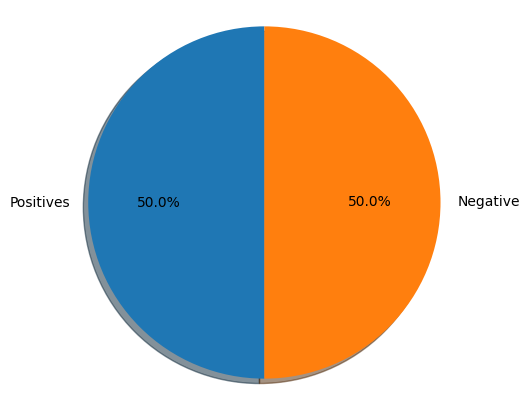

In [106]:
# Declare a figure with a custom size
fig = plt.figure(figsize=(5, 5))

# labels for the two classes
labels = 'Positives', 'Negative'

# Sizes for each slide
sizes = [len(all_positive_tweets), len(all_negative_tweets)]

# Declare pie chart, where the slices will be ordered and plotted counter-clockwise:
plt.pie(sizes, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)

# Equal aspect ratio ensures that pie is drawn as a circle.
plt.axis('equal')

# Display the chart
plt.show()


# Text Cleaning and Preprocessing

In [107]:
import re                                  # library for regular expression operations
import string                              # for string operations

from nltk.corpus import stopwords          # module for stop words that come with NLTK
from nltk.stem import PorterStemmer        # module for stemming
from nltk.tokenize import TweetTokenizer   # module for tokenizing strings

In [109]:
print('\033[92m' + tweet)
print('\033[94m')

# remove old style retweet text "RT"
tweet2 = re.sub(r'^RT[\s]+', '', tweet)

# remove hyperlinks
tweet2 = re.sub(r'https?:\/\/.*[\r\n]*', '', tweet2)

# remove hashtags
# only removing the hash # sign from the word
tweet2 = re.sub(r'#', '', tweet2)
tweet2 = re.sub(r'…', '', tweet2)

print(tweet2)

My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i

My beautiful sunflowers on a sunny Friday morning off :) sunflowers favourites happy Friday off 


In [110]:
print()
print('\033[92m' + tweet2)
print('\033[94m')

# instantiate tokenizer class
tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True,
                               reduce_len=True)

# tokenize tweets
tweet_tokens = tokenizer.tokenize(tweet2)

print()
print('Tokenized string:')
print(tweet_tokens)


My beautiful sunflowers on a sunny Friday morning off :) sunflowers favourites happy Friday off 


Tokenized string:
['my', 'beautiful', 'sunflowers', 'on', 'a', 'sunny', 'friday', 'morning', 'off', ':)', 'sunflowers', 'favourites', 'happy', 'friday', 'off']


In [111]:
## making text cleaning function
def clean_tweet(tweet):
    # remove old style retweet text "RT"
    clean_tweet = re.sub(r'^RT[\s]+', '', tweet)
    # remove hyperlinks
    clean_tweet = re.sub(r'https?:\/\/.*[\r\n]*', '', clean_tweet)
    # remove hashtags
    # only removing the hash # sign from the word
    clean_tweet = re.sub(r'#', '', clean_tweet)
    clean_tweet = re.sub(r'…', '', clean_tweet)
    # remove mentions
    clean_tweet = re.sub(r'@\w+', '', clean_tweet)
    return clean_tweet

all_positive_cleaned = [clean_tweet(tweet) for tweet in all_positive_tweets]
all_negative_cleaned = [clean_tweet(tweet) for tweet in all_negative_tweets]  

In [112]:
all_positive_tweets[227]

'@coffeebreak22 @LauRenArren @drparkave @JWKanyuira1969 @dheracing @RhoaChri @BarbaraBathurst @1cryingeye @willisteam :) ☕☕☕ Thank you Rita!'

In [113]:
all_positive_cleaned[227]

'         :) ☕☕☕ Thank you Rita!'

In [114]:
all_negative_tweets[227]

'@energybiebers Sigh... :('

In [115]:
all_negative_cleaned[227]

' Sigh... :('

In [116]:
# download the stopwords from NLTK
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/oybekeraliev/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [117]:
#Import the english stop words list from NLTK
stopwords_english = stopwords.words('english')

print('Stop words\n')
print(stopwords_english)

print('\nPunctuation\n')
print(string.punctuation)

Stop words

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "s

In [118]:
print(len(stopwords_english))

198


In [119]:
print()
print('\033[92m')
print(tweet_tokens)
print('\033[94m')

tweets_clean = []

for word in tweet_tokens: # Go through every word in your tokens list
    if (word not in stopwords_english and  # remove stopwords
        word not in string.punctuation):  # remove punctuation
        tweets_clean.append(word)

print('removed stop words and punctuation:')
print(tweets_clean)



['my', 'beautiful', 'sunflowers', 'on', 'a', 'sunny', 'friday', 'morning', 'off', ':)', 'sunflowers', 'favourites', 'happy', 'friday', 'off']

removed stop words and punctuation:
['beautiful', 'sunflowers', 'sunny', 'friday', 'morning', ':)', 'sunflowers', 'favourites', 'happy', 'friday']


In [120]:
def remove_stopwords(tweet):
    ## tokenize tweet
    tweet_tokens = tokenizer.tokenize(tweet)
    tweets_clean = []
    for word in tweet_tokens:
        if (word not in stopwords_english and  # remove stopwords
            word not in string.punctuation):  # remove punctuation
            tweets_clean.append(word)
    return tweets_clean

fin_all_positives = [remove_stopwords(tweet) for tweet in all_positive_cleaned]
fin_all_negatives = [remove_stopwords(tweet) for tweet in all_negative_cleaned]

In [121]:
len(fin_all_positives)

5000

In [122]:
fin_all_positives[227]

[':)', '☕', '☕', '☕', 'thank', 'rita']

In [123]:
fin_all_negatives[227]

['sigh', '...', ':(']

In [124]:
print()
print('\033[92m')
print(tweets_clean)
print('\033[94m')

# Instantiate stemming class
stemmer = PorterStemmer()

# Create an empty list to store the stems
tweets_stem = []

for word in tweets_clean:
    stem_word = stemmer.stem(word)  # stemming word
    tweets_stem.append(stem_word)  # append to the list

print('stemmed words:')
print(tweets_stem)



['beautiful', 'sunflowers', 'sunny', 'friday', 'morning', ':)', 'sunflowers', 'favourites', 'happy', 'friday']

stemmed words:
['beauti', 'sunflow', 'sunni', 'friday', 'morn', ':)', 'sunflow', 'favourit', 'happi', 'friday']


In [125]:
import nltk
from nltk.stem import WordNetLemmatizer

print()
print('\033[92m')
print(tweets_clean)
print('\033[94m')

# Instantiate stemming class
lemmatizer = WordNetLemmatizer()

# Create an empty list to store the stems
tweets_lem = []

for word in tweets_clean:
    lem_word = lemmatizer.lemmatize(word)  # stemming word
    tweets_lem.append(lem_word)  # append to the list

print('Lemmitized words:')
print(tweets_lem)



['beautiful', 'sunflowers', 'sunny', 'friday', 'morning', ':)', 'sunflowers', 'favourites', 'happy', 'friday']

Lemmitized words:
['beautiful', 'sunflower', 'sunny', 'friday', 'morning', ':)', 'sunflower', 'favourite', 'happy', 'friday']


In [149]:
def remove_stopwords_fin(tweet, stem=False, lemmitize=False):
    
    ## tokenize tweet
    tweet_tokens = tokenizer.tokenize(tweet)
    tweets_clean = []
    for word in tweet_tokens:
        if stem:
            stemmer = PorterStemmer()
            word = stemmer.stem(word)
        if lemmitize:
            lemmatizer = WordNetLemmatizer()
            word = lemmatizer.lemmatize(word)
        if (word not in stopwords_english and  # remove stopwords
            word not in string.punctuation):  # remove punctuation
            tweets_clean.append(word)
    return tweets_clean

In [170]:
all_positive_stemmed = [remove_stopwords_fin(tweet) for tweet in all_positive_cleaned]
all_negative_stemmed = [remove_stopwords_fin(tweet) for tweet in all_negative_cleaned]

In [171]:
all_positive_stemmed[0]

['followfriday', 'top', 'engaged', 'members', 'community', 'week', ':)']

In [172]:
all_negative_stemmed[227]

['sigh', '...', ':(']

## **Encoding the text data**

In [173]:
all_clean_tweets = all_positive_stemmed + all_negative_stemmed

### creating vocabulary set
vocab = set()
for tweet in all_clean_tweets:
    for word in tweet:
        vocab.add(word.lower())

len(vocab)

12337

In [174]:
### indexing vocabulary
word2index = {}
index2word = {}
for i, word in enumerate(vocab):
    word2index[word] = i
    index2word[i] = word

In [175]:
word2index

{'speak': 0,
 'ditched': 1,
 'wagga': 2,
 'fruit': 3,
 'harana': 4,
 'lice': 5,
 'seduce': 6,
 'salabraty': 7,
 'blowing': 8,
 'lollipop': 9,
 'consumed': 10,
 'vampire': 11,
 'sunjam': 12,
 'gue': 13,
 'occasionally': 14,
 'tagsforlikes': 15,
 'players': 16,
 'killua': 17,
 'regretting': 18,
 'execution': 19,
 'motherfucking': 20,
 'ylona': 21,
 'vianey': 22,
 '💙': 23,
 'manchester': 24,
 'woes': 25,
 'megamoh': 26,
 'manny': 27,
 'jennyjean': 28,
 'grandmother': 29,
 "sterling's": 30,
 'j8': 31,
 'affect': 32,
 'sopranos': 33,
 'ftw': 34,
 'lineup': 35,
 'adults': 36,
 'harumph': 37,
 'syrus': 38,
 'track': 39,
 'crazyyy': 40,
 'heated': 41,
 'timog': 42,
 'seafood': 43,
 'maker': 44,
 'valentine': 45,
 'kong': 46,
 'rear': 47,
 '. .': 48,
 'relapse': 49,
 'overweight': 50,
 'mashed': 51,
 'bapak': 52,
 'date': 53,
 'composer': 54,
 'producer': 55,
 'muted': 56,
 'zopiclone': 57,
 'afternoon': 58,
 "pixar's": 59,
 'back': 60,
 '35': 61,
 'situated': 62,
 'slippers': 63,
 'replacement

In [176]:
index2word

{0: 'speak',
 1: 'ditched',
 2: 'wagga',
 3: 'fruit',
 4: 'harana',
 5: 'lice',
 6: 'seduce',
 7: 'salabraty',
 8: 'blowing',
 9: 'lollipop',
 10: 'consumed',
 11: 'vampire',
 12: 'sunjam',
 13: 'gue',
 14: 'occasionally',
 15: 'tagsforlikes',
 16: 'players',
 17: 'killua',
 18: 'regretting',
 19: 'execution',
 20: 'motherfucking',
 21: 'ylona',
 22: 'vianey',
 23: '💙',
 24: 'manchester',
 25: 'woes',
 26: 'megamoh',
 27: 'manny',
 28: 'jennyjean',
 29: 'grandmother',
 30: "sterling's",
 31: 'j8',
 32: 'affect',
 33: 'sopranos',
 34: 'ftw',
 35: 'lineup',
 36: 'adults',
 37: 'harumph',
 38: 'syrus',
 39: 'track',
 40: 'crazyyy',
 41: 'heated',
 42: 'timog',
 43: 'seafood',
 44: 'maker',
 45: 'valentine',
 46: 'kong',
 47: 'rear',
 48: '. .',
 49: 'relapse',
 50: 'overweight',
 51: 'mashed',
 52: 'bapak',
 53: 'date',
 54: 'composer',
 55: 'producer',
 56: 'muted',
 57: 'zopiclone',
 58: 'afternoon',
 59: "pixar's",
 60: 'back',
 61: '35',
 62: 'situated',
 63: 'slippers',
 64: 'replace

In [177]:
def one_hot_encode(tweet, word_to_index, vocab_size):
    encoding = np.zeros(vocab_size, dtype=int)
    for word in tweet:
        if word in word_to_index:  # Ignore words not in the vocabulary
            encoding[word_to_index[word]] = 1
    return encoding

In [178]:
enc_positives = [one_hot_encode(tweet, word2index, len(vocab)) for tweet in all_positive_stemmed]
enc_negatives = [one_hot_encode(tweet, word2index, len(vocab)) for tweet in all_negative_stemmed]

In [179]:
enc_positives[0]

array([0, 0, 0, ..., 0, 0, 0], shape=(12337,))

In [180]:
enc_negatives[0]

array([0, 0, 0, ..., 0, 0, 0], shape=(12337,))

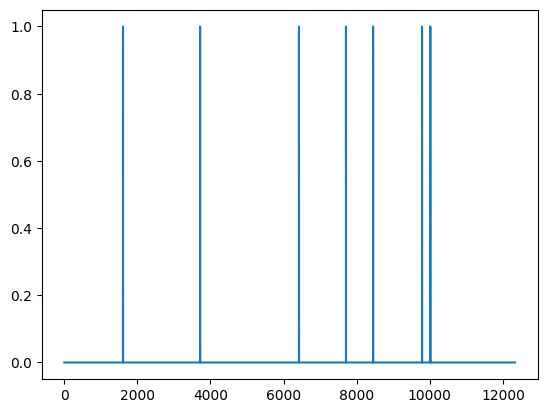

In [181]:
plt.plot(enc_positives[0])

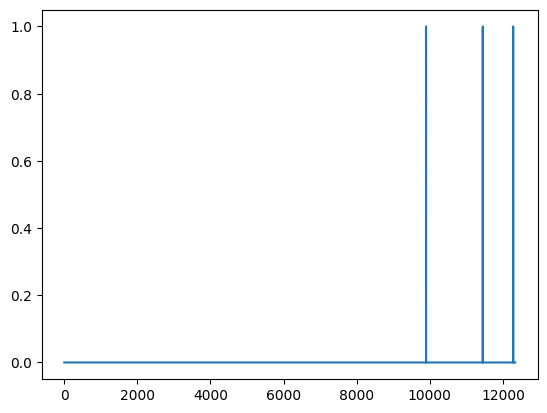

In [182]:
plt.plot(enc_negatives[227])

In [183]:
# Combine positive and negative encodings into one dataset
X = np.array(enc_positives + enc_negatives)  # Feature matrix
y = np.array([1] * len(enc_positives) + [0] * len(enc_negatives))  # Labels (1 = positive, 0 = negative)
X.shape, y.shape

((10000, 12337), (10000,))

In [184]:
y

array([1, 1, 1, ..., 0, 0, 0], shape=(10000,))

In [185]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(8000, 12337)
(2000, 12337)
(8000,)
(2000,)


In [186]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Step 4: Make predictions
y_pred = model.predict(X_test)

# Step 5: Evaluate the Model
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy of Logistic Regression model:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy of Logistic Regression model: 0.9945

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       988
           1       0.99      1.00      0.99      1012

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [187]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
# from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

# Step 3: Define the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine (SVM)": SVC(kernel='linear', probability=True),
    "Naive Bayes": MultinomialNB(),
    "K-Nearest Neighbors (KNN)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
    # "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Step 4: Train and evaluate each model
results = {}
for model_name, model in models.items():
    print(f"\nTraining {model_name}...")
    model.fit(X_train, y_train)  # Train the model
    y_pred = model.predict(X_test)  # Predict on test set
    accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy
    results[model_name] = accuracy  # Store accuracy for comparison
    print(f"{model_name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))

# Step 5: Display model performance comparison
print("\nModel Performance Comparison:")
for model_name, accuracy in results.items():
    print(f"{model_name}: {accuracy:.4f}")



Training Logistic Regression...
Logistic Regression Accuracy: 0.9945
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       988
           1       0.99      1.00      0.99      1012

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000


Training Support Vector Machine (SVM)...
Support Vector Machine (SVM) Accuracy: 0.9945
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       988
           1       0.99      1.00      0.99      1012

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000


Training Naive Bayes...
Naive Bayes Accuracy: 0.9650
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       988
           1       0.99  